Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 3778.4290 - mae: 59.3005 - val_loss: 3211.8337 - val_mae: 53.7448
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 3229.8901 - mae: 54.6474 - val_loss: 2657.4370 - val_mae: 48.4696
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 2740.8240 - mae: 50.0910 - val_loss: 2169.0784 - val_mae: 43.3003
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 2303.7354 - mae: 45.5834 - val_loss: 1742.7220 - val_mae: 38.1755
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 1917.3250 - mae: 41.1340 - val_loss: 1376.2772 - val_mae: 33.0982
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1580.8521 - mae: 36.7320 - val_loss: 1070.9333 - val_mae: 28.1298
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1294.5203 - mae: 32.4097 - val_loss: 826.7701 - val_mae: 23.5407
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1057.9526 - mae: 28.2239 - val_loss: 637.3975 - val_mae: 20.3738
Epoch 9/100


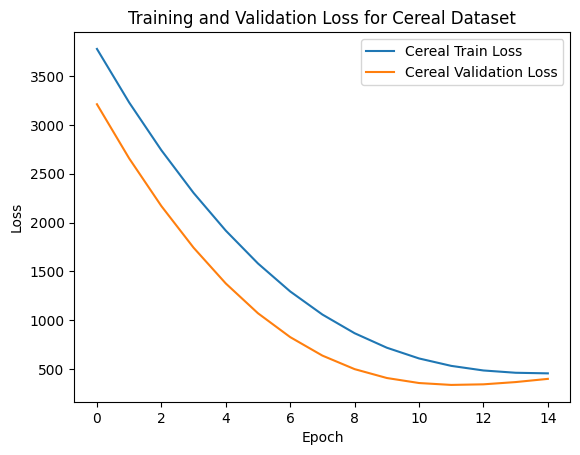

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras import Input
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

# Load datasets from Kaggle
# Make sure you have your Kaggle API key set up properly to use the Kaggle datasets
# Here, we assume you've already downloaded the datasets and placed them in your working directory
# cereal_data = pd.read_csv("cereal.csv")
cereal_data = pd.read_csv("https://github.com/ML-Course-2026/session5/raw/refs/heads/main/material/datasets/cereal.csv")
# Preprocess dataset
# For simplicity, we'll use only a subset of features for the dataset and treat it as a regression problem
cereal_features = cereal_data[['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins']]
cereal_target = cereal_data['rating']

# Split dataset into training and testing sets
cereal_X_train, cereal_X_test, cereal_y_train, cereal_y_test = train_test_split(cereal_features, cereal_target, test_size=0.2, random_state=42)

# Define a Sequential model
model = Sequential()
model.add(Input(shape=(cereal_X_train.shape[1],)))

# Add dense layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))# Output layer for regression task

# Compile the model
model.compile(optimizer='adam',
              loss='mean_squared_error',  # Use MSE loss for regression
              metrics=['mae'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

# Print model summary
model.summary()

# Train the model with early stopping
history_cereal = model.fit(cereal_X_train, cereal_y_train, epochs=100, batch_size=64,
                            validation_data=(cereal_X_test, cereal_y_test),
                            callbacks=[early_stopping], verbose=1)

# Plot training history for cereal dataset
plt.plot(history_cereal.history['loss'], label='Cereal Train Loss')
plt.plot(history_cereal.history['val_loss'], label='Cereal Validation Loss')

plt.title('Training and Validation Loss for Cereal Dataset')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()